In [160]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from torch.optim.lr_scheduler import ReduceLROnPlateau


In [ ]:
# 1. Load the dataset
df = pd.read_csv("housing.csv")

#  Data Preprocessing
if df['AveBedrms'].isna().sum() > 0:
    df['AveBedrms'].fillna(df['AveBedrms'].median(), inplace=True)

# 3. Feature Engineering

df['rooms_per_household'] = df['AveRooms']
df['bedrooms_per_room'] = df['AveBedrms'] / df['AveRooms']
df['population_per_household'] = df['Population'] / df['AveOccup']
df['income_per_room'] = df['MedInc'] / df['AveRooms']


df['house_age_squared'] = df['HouseAge'] ** 2
df['income_squared'] = df['MedInc'] ** 2
df['rooms_squared'] = df['AveRooms'] ** 2
df['latitude_squared'] = df['Latitude'] ** 2
df['longitude_squared'] = df['Longitude'] ** 2

df['lat_long_interaction'] = df['Latitude'] * df['Longitude']
df['income_age_interaction'] = df['MedInc'] * df['HouseAge']
df['income_rooms_interaction'] = df['MedInc'] * df['AveRooms']
df['age_rooms_interaction'] = df['HouseAge'] * df['AveRooms']

df = pd.get_dummies(df, columns=['ocean_proximity'], drop_first=False)
df['dist_to_coast'] = 1.0  
if 'ocean_proximity_NEAR OCEAN' in df.columns:
    df['dist_to_coast'] -= 0.5 * df['ocean_proximity_NEAR OCEAN']
if 'ocean_proximity_ISLAND' in df.columns:
    df['dist_to_coast'] -= 0.8 * df['ocean_proximity_ISLAND']
if 'ocean_proximity_OCEAN' in df.columns:
    df['dist_to_coast'] -= 0.9 * df['ocean_proximity_OCEAN']


df['dist_to_center'] = np.sqrt((df['Latitude'] - df['Latitude'].mean()) ** 2 +
                               (df['Longitude'] - df['Longitude'].mean()) ** 2)

df['room_density'] = df['AveRooms'] / df['Population']
df['household_density'] = df['AveOccup'] / df['Population']

df['income_high'] = (df['MedInc'] > df['MedInc'].quantile(0.75)).astype(int)
df['income_low'] = (df['MedInc'] < df['MedInc'].quantile(0.25)).astype(int)


df['income_block'] = df.groupby(['Latitude', 'Longitude'])['MedInc'].transform('mean')

# Log transform
df['Population'] = np.log1p(df['Population'])

# 4. Split features and target
X = df.drop('MedHouseVal', axis=1)
y = df['MedHouseVal'].values.reshape(-1, 1)

#  features scaling
X_scaler = StandardScaler()
y_scaler = StandardScaler()
X_scaled = X_scaler.fit_transform(X)
y_scaled = y_scaler.fit_transform(y)

#  Conversion to PyTorch tensors
X_tensor = torch.tensor(X_scaled, dtype=torch.float32)
y_tensor = torch.tensor(y_scaled, dtype=torch.float32)

#  Test split
X_train, X_temp, y_train, y_temp = train_test_split(X_tensor, y_tensor, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

train_ds = TensorDataset(X_train, y_train)
val_ds = TensorDataset(X_val, y_val)
test_ds = TensorDataset(X_test, y_test)

train_dl = DataLoader(train_ds, batch_size=32, shuffle=True)
val_dl = DataLoader(val_ds, batch_size=32)
test_dl = DataLoader(test_ds, batch_size=32)

print(f"Features shape: {X_tensor.shape}")
print(f"Target shape: {y_tensor.shape}")
print(f"Training set: {len(train_ds)}")
print(f"Validation set: {len(val_ds)}")
print(f"Test set: {len(test_ds)}")

Features shape: torch.Size([20640, 32])
Target shape: torch.Size([20640, 1])
Training set: 14448
Validation set: 3096
Test set: 3096


In [162]:
class CaliforniaHousingPredictor(nn.Module):
    def __init__(self, input_size):
        super().__init__()
        self.network = nn.Sequential(
    nn.Linear(input_size, 128),
    nn.ReLU(),
    nn.BatchNorm1d(128),
    nn.Dropout(0.3),
    nn.Linear(128, 128),  
    
    nn.BatchNorm1d(128),
    nn.Dropout(0.2),
    nn.Linear(128, 64),
    nn.ReLU(),
    nn.Linear(64, 32),
    nn.ReLU(),
    nn.Linear(32, 1)
)

        
    
    def forward(self, x):
        return self.network(x)


In [ ]:
model = CaliforniaHousingPredictor(X_tensor.shape[1])
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.0005, weight_decay=0.001)
scheduler = ReduceLROnPlateau(optimizer, mode='min', patience=3, factor=0.5)

best_loss = float('inf')
patience = 10
patience_counter = 0

for epoch in range(100):
    model.train()
    for xb, yb in train_dl:
        pred = model(xb)
        loss = criterion(pred, yb)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        optimizer.zero_grad()

    model.eval()
    with torch.no_grad():
        val_preds = model(X_val)
        val_loss = criterion(val_preds, y_val)

    val_rmse = torch.sqrt(val_loss).item()
    print(f"Epoch {epoch+1}, Val RMSE: {val_rmse:.4f}")

    scheduler.step(val_loss)

    if val_loss < best_loss:
        best_loss = val_loss
        best_model_state = model.state_dict()
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print("Early stopping triggered.")
            break



Epoch 1, Val RMSE: 0.5575
Epoch 2, Val RMSE: 0.5310
Epoch 3, Val RMSE: 0.5308
Epoch 4, Val RMSE: 0.5207
Epoch 5, Val RMSE: 0.5079
Epoch 6, Val RMSE: 0.5017
Epoch 7, Val RMSE: 0.5141
Epoch 8, Val RMSE: 0.5114
Epoch 9, Val RMSE: 0.5027
Epoch 10, Val RMSE: 0.4984
Epoch 11, Val RMSE: 0.5055
Epoch 12, Val RMSE: 0.4943
Epoch 13, Val RMSE: 0.4962
Epoch 14, Val RMSE: 0.4940
Epoch 15, Val RMSE: 0.4861
Epoch 16, Val RMSE: 0.4907
Epoch 17, Val RMSE: 0.4974
Epoch 18, Val RMSE: 0.4873
Epoch 19, Val RMSE: 0.5122
Epoch 20, Val RMSE: 0.4773
Epoch 21, Val RMSE: 0.4769
Epoch 22, Val RMSE: 0.5063
Epoch 23, Val RMSE: 0.4745
Epoch 24, Val RMSE: 0.4784
Epoch 25, Val RMSE: 0.4734
Epoch 26, Val RMSE: 0.5008
Epoch 27, Val RMSE: 0.4745
Epoch 28, Val RMSE: 0.4745
Epoch 29, Val RMSE: 0.4933
Epoch 30, Val RMSE: 0.4685
Epoch 31, Val RMSE: 0.4670
Epoch 32, Val RMSE: 0.4705
Epoch 33, Val RMSE: 0.4693
Epoch 34, Val RMSE: 0.4730
Epoch 35, Val RMSE: 0.4740
Epoch 36, Val RMSE: 0.4678
Epoch 37, Val RMSE: 0.4687
Epoch 38, 

In [ ]:
# evaluation
model.eval()
with torch.no_grad():
    test_preds = model(X_test)

# Conversion to numpy
test_preds_np = test_preds.numpy()
y_true = y_test.numpy()

# Inverse scaling
y_true_inv = y_scaler.inverse_transform(y_true)
preds_inv = y_scaler.inverse_transform(test_preds_np)

rmse = np.sqrt(mean_squared_error(y_true_inv, preds_inv))
mae = mean_absolute_error(y_true_inv, preds_inv)
r2 = r2_score(y_true_inv, preds_inv)

print("\n🔍 Model Evaluation Metrics:")
print(f"✅ RMSE: {rmse:.4f}")
print(f"✅ MAE : {mae:.4f}")
print(f"✅ R²  : {r2:.4f}")

if r2 >= 0.85:
    print("🎉 SUCCESS! R² target of 0.85 achieved!")
else:
    print(f"📈 Progress: Need {0.85 - r2:.4f} more to reach 0.85")


🔍 Model Evaluation Metrics:
✅ RMSE: 0.5104
✅ MAE : 0.3599
✅ R²  : 0.8030
📈 Progress: Need 0.0470 more to reach 0.85


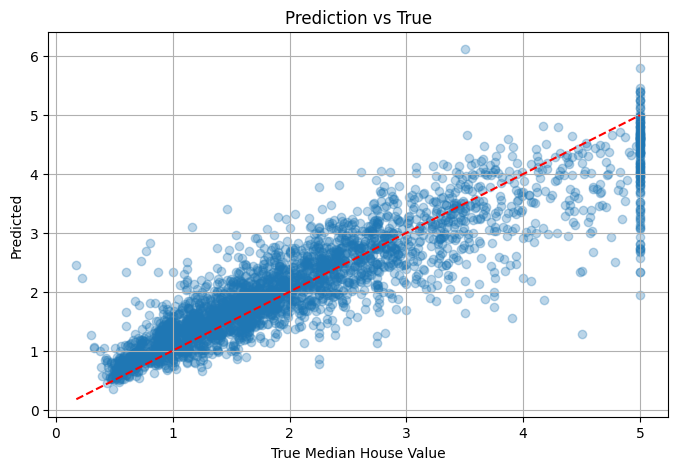

In [ ]:
# Visualization of predictions 
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.scatter(y_true_inv, preds_inv, alpha=0.3)
plt.plot([y_true_inv.min(), y_true_inv.max()],
         [y_true_inv.min(), y_true_inv.max()], 'r--')
plt.xlabel("True Median House Value")
plt.ylabel("Predicted")
plt.title("Prediction vs True")
plt.grid()
plt.show()
